In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("bodyPerformance.csv")

df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [ ]:
df.describe()

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


The dataset contains 13,393 observations.
The statistical summary shows the mean, standard deviation, minimum, quartiles, and maximum for all numeric attributes.

The variable “sit and bend forward_cm” contains negative values, which may represent flexibility test results.

Some attributes show a large gap between the 75th percentile and maximum value (e.g., weight_kg, systolic, broad jump_cm), which may indicate the presence of outliers.

In [ ]:
numeric_cols = df.select_dtypes(include=np.number)

five_number_summary = numeric_cols.describe().loc[['min','25%','50%','75%','max']]
five_number_summary

,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
min,21.0,125.0,26.3,3.0,0.0,0.0,0.0,-25.0,0.0,0.0
25%,25.0,162.4,58.2,18.0,71.0,120.0,27.5,10.9,30.0,162.0
50%,32.0,169.2,67.4,22.8,79.0,130.0,37.9,16.2,41.0,193.0
75%,48.0,174.8,75.3,28.0,86.0,141.0,45.2,20.7,50.0,221.0
max,64.0,193.8,138.1,78.4,156.2,201.0,70.5,213.0,80.0,303.0


The five-number summary was calculated for all numeric attributes, including minimum, first quartile (Q1), median, third quartile (Q3), and maximum.

The results show variability in several attributes such as weight_kg, systolic, and broad jump_cm, where there is a large difference between Q3 and the maximum value.

The attribute "sit and bend forward_cm" includes negative values and a very large maximum value (213), indicating potential extreme values that may require further investigation.

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
height_cm,0
weight_kg,0
body fat_%,0
diastolic,0
systolic,0
gripForce,0
sit and bend forward_cm,0
sit-ups counts,0


The missing value analysis was performed using df.isnull().sum().
The results show that there are no missing values in any of the attributes.

This indicates that the dataset is complete and does not require missing value imputation or removal of incomplete records.


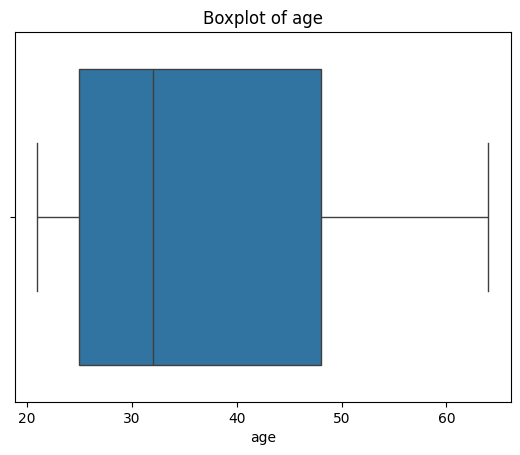

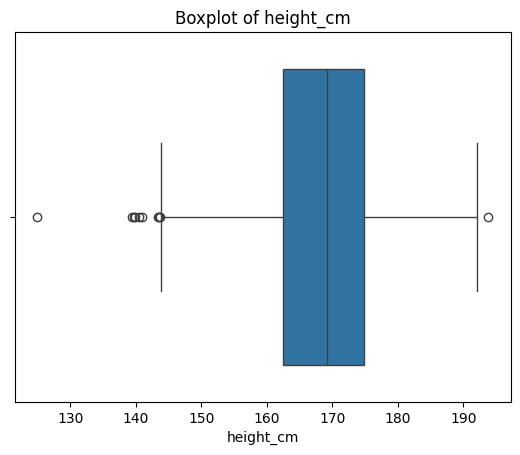

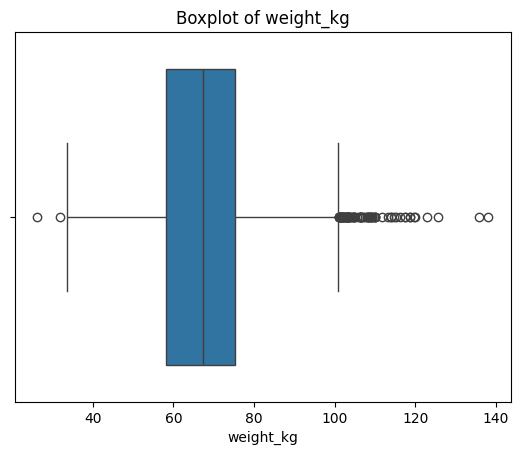

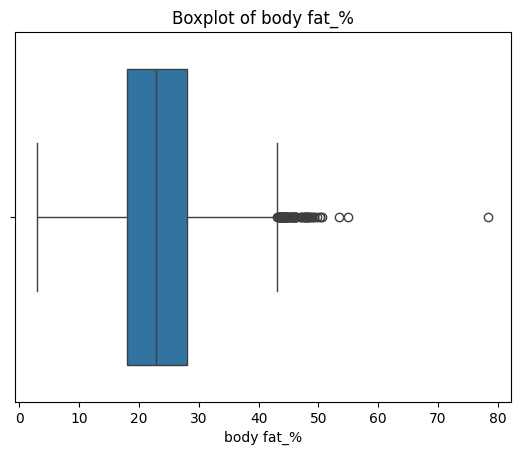

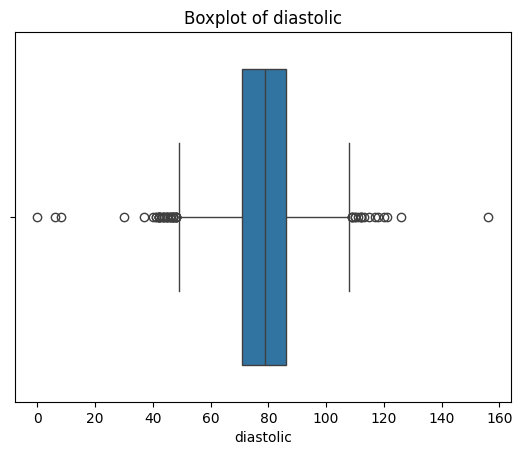

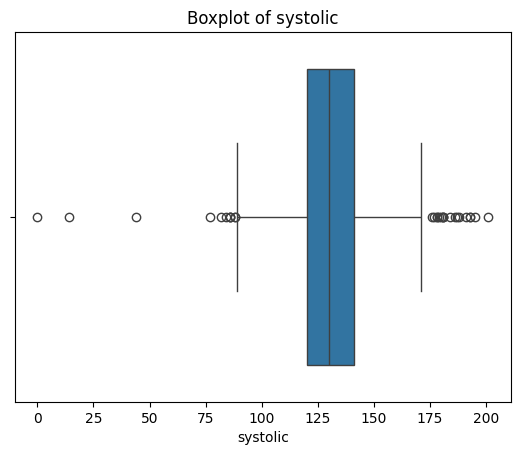

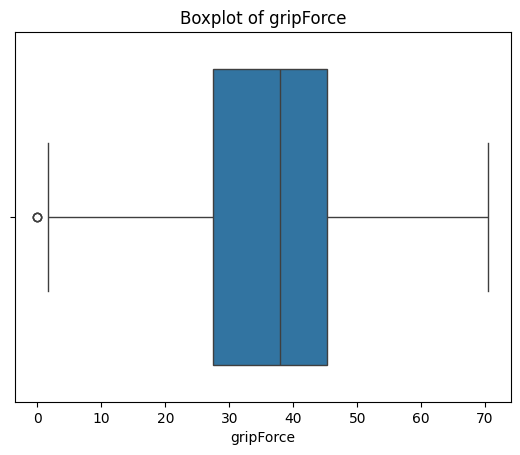

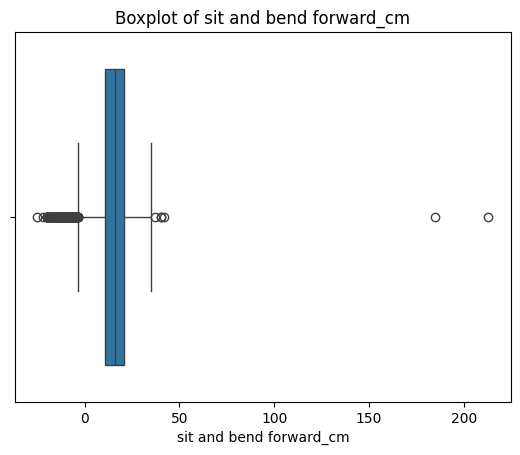

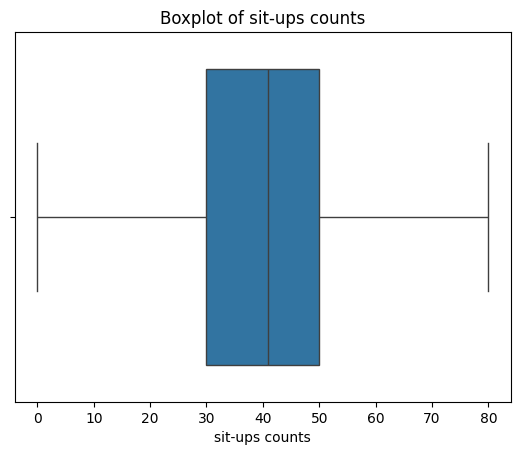

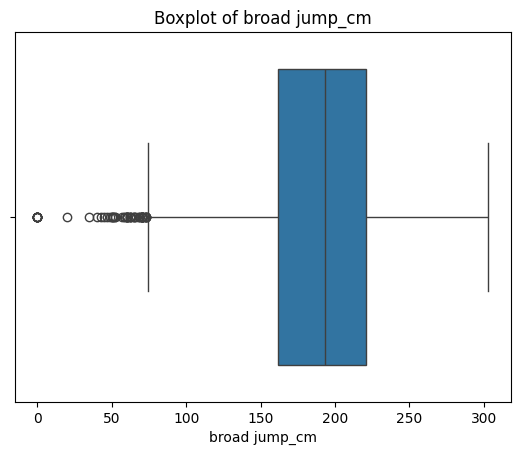

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=np.number)

for col in numeric_cols.columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Boxplots were used to visually detect potential outliers in the dataset. Several attributes such as weight_kg, body fat_%, systolic, diastolic, and sit and bend forward_cm show noticeable outliers. In particular, sit and bend forward_cm contains extreme upper values exceeding 200 cm, which may require preprocessing  Other attributes like age and sit-ups counts show relatively stable distributions with minimal outliers. These observations indicate that preprocessing techniques such as normalization or outlier handling may be required.

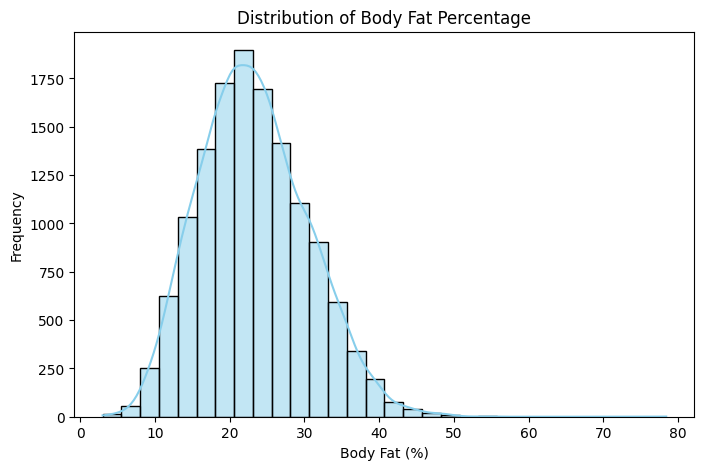

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='body fat_%', bins=30, kde=True, color='skyblue')
plt.title('Distribution of Body Fat Percentage')
plt.xlabel('Body Fat (%)')
plt.ylabel('Frequency')
plt.show()

The histogram displays the distribution of the 'body fat_%' numeric attribute. As observed, the data exhibits a slight right skew, indicating the presence of potential outliers with unusually high body fat values (extending towards the 60-80 range). This non-normal distribution suggests that we need to apply Outlier Handling or Data Normalization during the preprocessing phase to prevent these extreme values from skewing the machine learning model's predictions.

/tmp/ipython-input-3546551944.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='gender', palette='Set2')


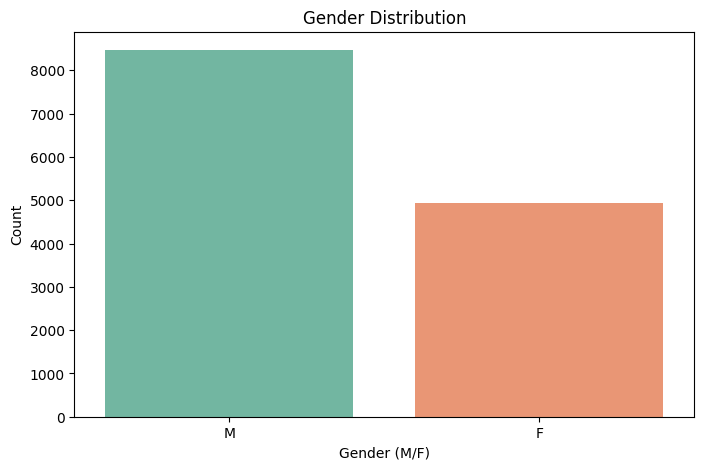

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender', palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender (M/F)')
plt.ylabel('Count')
plt.show()

This bar plot illustrates the distribution of nominal data, specifically the 'gender' attribute (Male vs. Female). Since machine learning models primarily require numerical inputs to perform calculations and find patterns, this nominal attribute explicitly dictates the need for Variable Transformation (such as Label Encoding or One-Hot Encoding) in the subsequent preprocessing step to convert letters (M/F) into numbers (0/1).

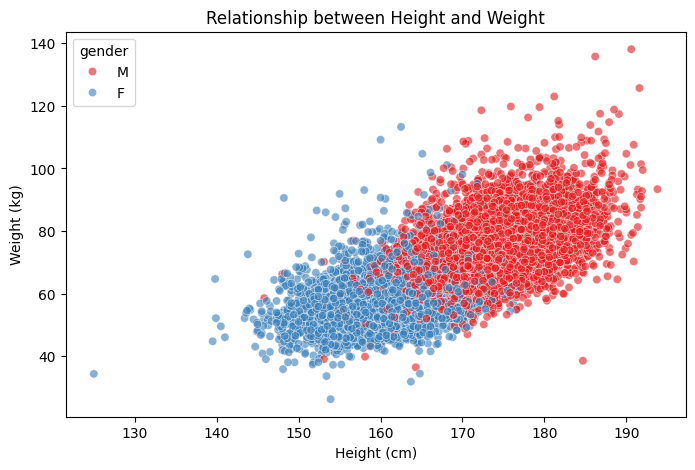

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='height_cm', y='weight_kg', hue='gender', alpha=0.6, palette='Set1')
plt.title('Relationship between Height and Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

The scatter plot reveals the relationship between height and weight among the individuals in the dataset, categorized by gender. Notably, there are a few isolated data points lying far away from the main cluster (e.g., extremely high weight relative to an average height). These visually represent potential noise or physical outliers. Identifying these instances confirms that Noise Removal or outlier handling is required to improve overall data quality before training the model.

/tmp/ipython-input-186363185.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', order=['A', 'B', 'C', 'D'], palette='viridis')


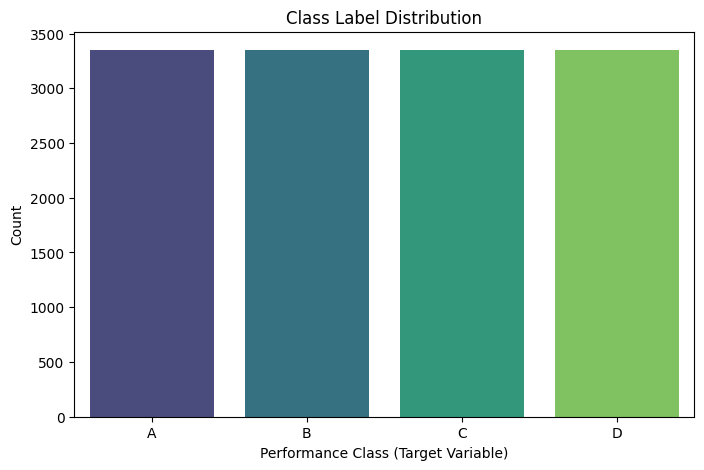

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', order=['A', 'B', 'C', 'D'], palette='viridis')
plt.title('Class Label Distribution')
plt.xlabel('Performance Class (Target Variable)')
plt.ylabel('Count')
plt.show()

This plot demonstrates the distribution of the target class labels (A, B, C, and D). Monitoring the class distribution is a critical step to ensure our predictive model doesn't become biased. Fortunately, the classes appear to be evenly balanced. However, similar to the gender attribute, these alphabetical labels (A-D) must be mapped and transformed into a numerical format (e.g., 0, 1, 2, 3) using Label Encoding during the preprocessing phase to be computationally interpretable by the target machine learning algorithm.

In [ ]:
df_raw = pd.read_csv("bodyPerformance.csv")
df = df_raw.copy()
df_raw.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

k = 3  # threshold
means = df[num_cols].mean()
stds  = df[num_cols].std()

lower = means - k * stds
upper = means + k * stds

df[num_cols] = df[num_cols].clip(lower=lower, upper=upper, axis=1)

We handled outliers using the standard deviation method. Instead of removing records, extreme values were limited to reduce their impact on the dataset.


In [ ]:
df_out=df.copy()
df_trans = df_out.copy()

df_trans["body fat_%_log"] = np.log1p(df_trans["body fat_%"])

A variable transformation (log transformation) was applied to reduce skewness and improve data distribution.

In [ ]:
df_trans.isnull().sum()

,0
age,0
gender,0
height_cm,0
weight_kg,0
body fat_%,0
diastolic,0
systolic,0
gripForce,0
sit and bend forward_cm,0
sit-ups counts,0


We examined the dataset for missing values.
No missing values were found, so no preprocessing action was needed.

In [ ]:
df["gender"] = df["gender"].map({"M": 1, "F": 0})
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


The gender column was converted into numerical values (Male = 1, Female = 0).
This transformation was necessary because machine learning algorithms require numerical input rather than categorical text values.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()


num_cols = df.select_dtypes(include=np.number).columns

num_cols = num_cols.drop("gender")

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,0.139535,1,0.574425,0.608688,0.435603,0.518667,0.497340,0.781355,0.562884,0.7500,0.630067,C
1,0.093023,1,0.429928,0.337550,0.302304,0.472121,0.452032,0.491155,0.521496,0.6625,0.681685,A
2,0.232558,1,0.718923,0.647182,0.407039,0.704852,0.746537,0.622921,0.436751,0.6125,0.475211,C
3,0.255814,1,0.617973,0.550945,0.366573,0.456606,0.689901,0.569587,0.499817,0.6625,0.638670,B
4,0.162791,1,0.604117,0.503524,0.335629,0.363514,0.463359,0.602529,0.734346,0.5625,0.630067,B


Min-Max normalization was applied to the numerical features to scale their values between 0 and 1.
Categorical variables such as gender and the target variable (class) were excluded from scaling.
This preprocessing step ensures that all numerical features have comparable ranges and prevents features with larger values from dominating the model.

In [ ]:
df.to_csv("Preprocessed_dataset.csv", index=False)